<a href="https://colab.research.google.com/github/imharshmishra87/Feature-Scaling-Ml/blob/main/Function_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot  as plt
import scipy.stats as stats
df=pd.read_csv("/content/fish_data.csv")
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.preprocessing import FunctionTransformer

In [ ]:
df.head()

,species,length,weight,w_l_ratio
0,Anabas testudineus,10.66,3.45,0.32
1,Anabas testudineus,6.91,3.27,0.47
2,Anabas testudineus,8.38,3.46,0.41
3,Anabas testudineus,7.57,3.36,0.44
4,Anabas testudineus,10.83,3.38,0.31


# Train, Test, Split Of Data

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop(['species'],axis=1),df['species'],test_size=0.1)

# Analysis Of columns Using QQ Plots And Distplot (Before Transformation)

/tmp/ipython-input-858383168.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['length'])


Text(0.5, 1.0, 'QQ Plot')

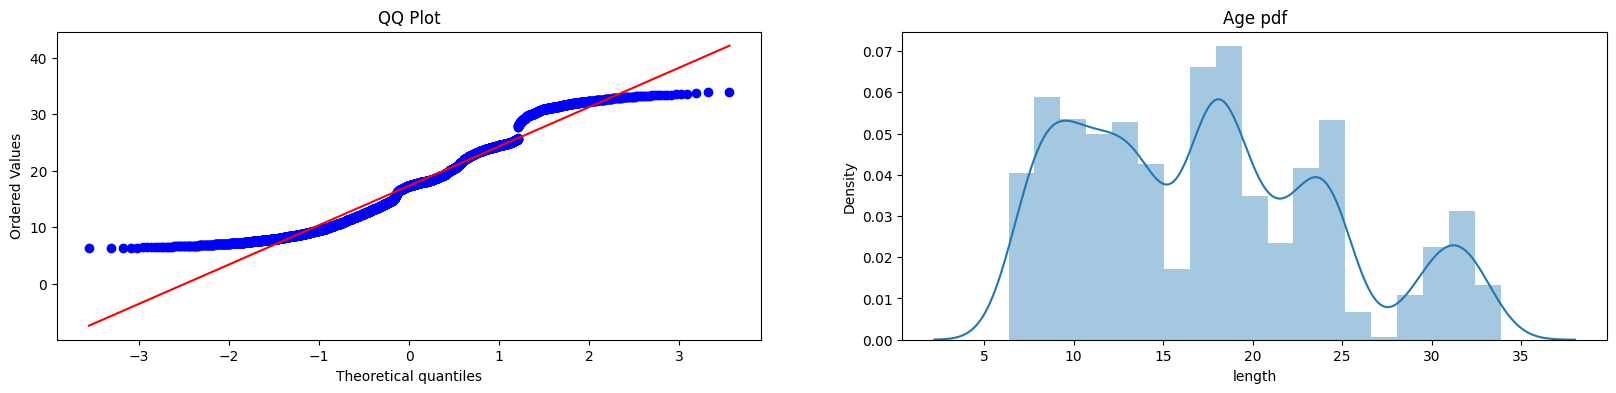

In [ ]:
# Analysing The length whether it is normal or not
plt.figure(figsize=(20,4))
plt.subplot(122)
sns.distplot(X_train['length'])
plt.title('Age pdf')

plt.subplot(121)
stats.probplot(X_train['length'],dist='norm',plot=plt)
plt.title('QQ Plot')

/tmp/ipython-input-1363996777.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['weight'])


Text(0.5, 1.0, 'QQ plot')

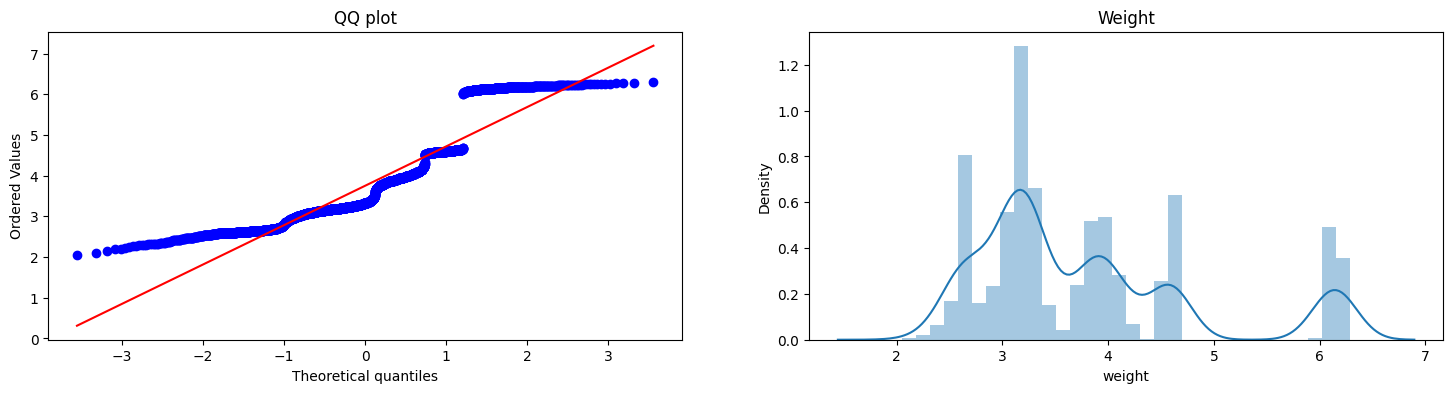

In [ ]:
# Analysing the weight
plt.figure(figsize=(18,4))
plt.subplot(122)
sns.distplot(X_train['weight'])
plt.title('Weight')

plt.subplot(121)
stats.probplot(X_train['weight'],dist='norm',plot=plt)
plt.title('QQ plot')

/tmp/ipython-input-2460314057.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['w_l_ratio'])


Text(0.5, 1.0, 'QQ plot')

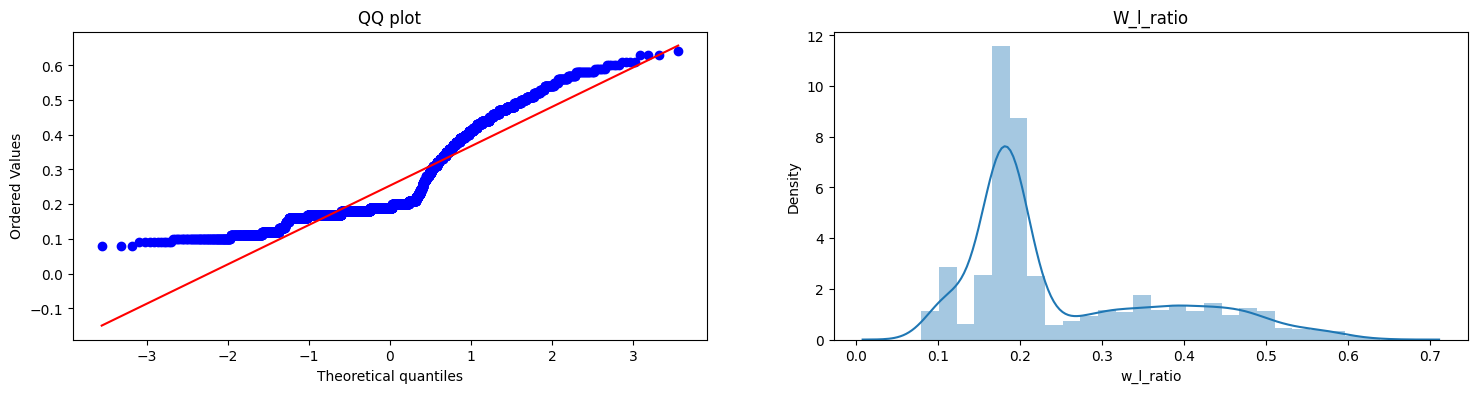

In [ ]:
# Analysing the weight
plt.figure(figsize=(18,4))
plt.subplot(122)
sns.distplot(X_train['w_l_ratio'])
plt.title('W_l_ratio')

plt.subplot(121)
stats.probplot(X_train['w_l_ratio'],dist='norm',plot=plt)
plt.title('QQ plot')

# Model Without Function Transformation

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

clf=LogisticRegression()
clf2=DecisionTreeClassifier()

clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


DecisionTreeClassifier()

In [ ]:
y_pred=clf.predict(X_test)
y_pred2=clf2.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)*100
accuracy2=accuracy_score(y_test,y_pred2)*100

print("Accuracy Achieved using logistic regression {}".format(accuracy))
print("Accuracy Achieved using Decision Tree Classifier {}".format(accuracy2))

Accuracy Achieved using logistic regression 85.04901960784314
Accuracy Achieved using Decision Tree Classifier 92.40196078431373


# Implementation Of Pipeline With Log Transformation

In [ ]:
from sklearn.compose import ColumnTransformer
tfs1=ColumnTransformer(transformers=[('functionTransform',FunctionTransformer(np.log1p),[0,1,2])],remainder='passthrough')



In [ ]:
from sklearn.linear_model import LogisticRegression
tfs2=LogisticRegression()


In [ ]:
pipe=Pipeline([('tfs1',tfs1),('tfs2',tfs2)])

In [ ]:
pipe.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('tfs1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('functionTransform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>),
                                                  [0, 1, 2])])),
                ('tfs2', LogisticRegression())])

In [ ]:
y_predict=pipe.predict(X_test)
np.mean(y_predict==y_test)

np.float64(0.9117647058823529)

# Cross Val Score Analysis

In [ ]:
from sklearn.model_selection import cross_val_score
val=cross_val_score(estimator=pipe, X=X_train,y=y_train,cv=5,scoring='balanced_accuracy').mean()*100
print("Model Accuracy is : {} %".format(val))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Model Accuracy is : 90.98325838544162 %


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
df.head(5)
for i in range(len(df.columns)):
  print(i, df.columns[i])
df.iloc[:,1:4]
df.iloc[:,0]

0 species
1 length
2 weight
3 w_l_ratio


,species
0,Anabas testudineus
1,Anabas testudineus
2,Anabas testudineus
3,Anabas testudineus
4,Anabas testudineus
...,...
4075,Sillaginopsis panijus
4076,Sillaginopsis panijus
4077,Sillaginopsis panijus
4078,Sillaginopsis panijus


# A function That Is Used To Perform Function Transformation

In [ ]:
def apply_transform(transform):
  x=df.iloc[:,1:4]
  y=df.iloc[:,0]
  tfs1=ColumnTransformer(transformers=[('transformed_data',FunctionTransformer(transform),['length'])],remainder='passthrough')
  transformed_X=tfs1.fit_transform(x)
  model=LogisticRegression()
  accuracy=cross_val_score(estimator=model, X=transformed_X, y=y,scoring='balanced_accuracy',cv=5).mean()*100
  print('The Accuracy of the model is {}'.format(accuracy))

  plt.figure(figsize=(12,4))
  plt.subplot(121)
  stats.probplot(x['length'],dist='norm',plot=plt)

  plt.subplot(122)
  stats.probplot(transformed_X[:,0],dist='norm',plot=plt)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

The Accuracy of the model is 92.07595633146838


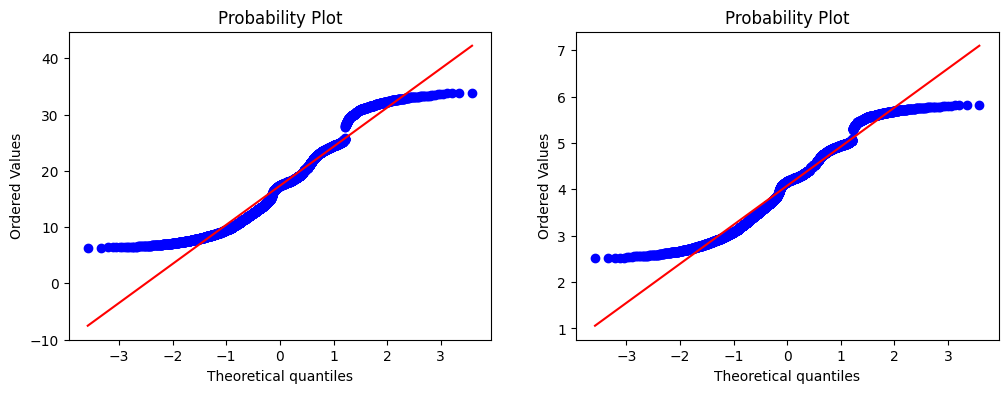

In [ ]:

apply_transform(lambda x: x**0.5)

